# SDE vs. SGD Model Comparison

---

Stochastic Gradient Descent (SGD) is a simple yet efficient approach to fitting linear classifiers and regressors under convex loss functions. In this framework, SGD can be modeled as a **Stochastic Differential Equation (SDE)**, providing a continuous-time approximation of the optimization dynamics influenced by Brownian motion. The governing equation is:

$$d\theta_t = -\nabla L(\theta_t) dt + \sqrt{2\gamma B(\theta_t)} dW_t$$

Where:
* $L(\theta)$: The loss function (Potential Energy).
* $B(\theta)$: The noise covariance tensor (Diffusion matrix).
* $\gamma$: The noise scale parameter (Temperature).
* $W_t$: A standard Wiener process (Stochastic noise).



### Numerical Integration: The Euler-Maruyama Method

Because the Wiener process $W_t$ is nowhere differentiable, standard Newtonian calculus cannot be applied. To simulate the trajectory of $\theta_t$ numerically, we employ the **Euler-Maruyama (EM)** method, which discretizes the SDE over a time interval $\Delta t$.

#### 1. Integration over Time Steps
We integrate the SDE over the discrete interval $[t, t + \Delta t]$:
$$\theta_{t+\Delta t} = \theta_t + \int_{t}^{t+\Delta t} -\nabla L(\theta_s) ds + \int_{t}^{t+\Delta t} \sqrt{2\gamma B(\theta_s)} dW_s$$

#### 2. First-Order Approximation
By assuming the drift ($-\nabla L$) and diffusion ($\sqrt{2\gamma B}$) coefficients remain constant over the infinitesimal interval $\Delta t$, we approximate the integrals:
$$\theta_{n+1} \approx \theta_n - \nabla L(\theta_n) \Delta t + \sqrt{2\gamma B(\theta_n)} (W_{t_{n+1}} - W_{t_n})$$

#### 3. The Wiener Increment
The term $\Delta W_n = W_{t_{n+1}} - W_{t_n}$ is the **Wiener increment**. By the properties of Brownian motion, this increment follows a normal distribution with mean $0$ and variance $\Delta t$:
$$\Delta W_n \sim \mathcal{N}(0, \Delta t)$$



#### 4. Final Simulation Rule
In implementation, we represent the increment by sampling $\epsilon \sim \mathcal{N}(0, I)$ and scaling it by $\sqrt{\Delta t}$. This yields the recursive update rule used in our simulator:
$$\theta_{n+1} = \theta_n - \nabla L(\theta_n) \Delta t + \sqrt{2\gamma B(\theta_n) \Delta t} \cdot \epsilon$$

First, let's implement the necessary libraries. We will be using the following:

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

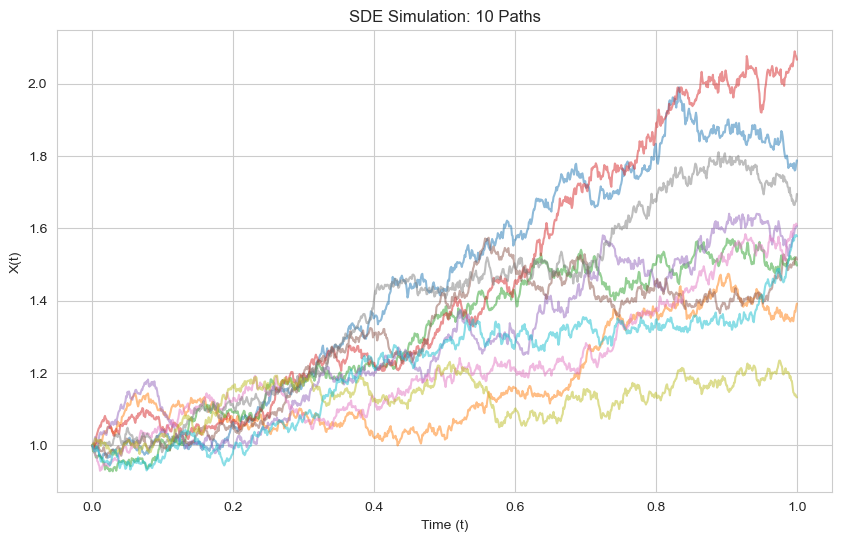

In [4]:
# From src/models/sde_simulator.py, we will implement our code here:

class SDESimulator:
    def __init__(self, drift_func, diffusion_func, paths, points, T=1.0, X0=0.0):
        """
        Initializes the SDE simulator (dX = drift*dt + diffusion*dW).
        """
        self.drift_func = drift_func
        self.diffusion_func = diffusion_func
        self.paths = paths
        self.points = points
        self.T = T
        self.X0 = X0
        self.dt = T / (points - 1)
        self.t_axis = np.linspace(0, T, points)

    def simulate(self):
        """Simulates paths using Euler-Maruyama method."""
        X = np.zeros((self.paths, self.points))
        X[:, 0] = self.X0
        
        # Standard normal random variables for Weiner process
        dW = np.random.normal(0, np.sqrt(self.dt), (self.paths, self.points - 1))
        
        for i in range(self.points - 1):
            X[:, i+1] = X[:, i] + \
                        self.drift_func(X[:, i], self.t_axis[i]) * self.dt + \
                        self.diffusion_func(X[:, i], self.t_axis[i]) * dW[:, i]
        return X

    def plot_paths(self, X):
        """Plots simulation paths."""
        plt.figure(figsize=(10, 6))
        sns.set_style("whitegrid")
        plt.plot(self.t_axis, X.T, alpha=0.5)
        plt.title(f"SDE Simulation: {self.paths} Paths")
        plt.xlabel("Time (t)")
        plt.ylabel("X(t)")
        plt.show()

# --- Test Case ---
if __name__ == '__main__':
    # Example: Geometric Brownian Motion (drift_func=mu*x, diff_func=sigma*x)
    mu, sigma = 0.5, 0.2
    
    # Define SDE functions
    drift = lambda x, t: mu * x
    diffusion = lambda x, t: sigma * x
    
    # Run simulation
    sim = SDESimulator(drift, diffusion, paths=10, points=1000, T=1.0, X0=1.0)
    X = sim.simulate()
    
    # Visualize
    sim.plot_paths(X)


### Stochastic Trajectories and Brownian Motion

The jagged, non-linear paths observed in the simulation are the realized trajectories of a stochastic process known as **Brownian motion** (or a Wiener process). Originating from thermodynamics, this motion describes the random walk of particles suspended in a medium. In the context of optimization, this randomness represents the "noise" inherent in mini-batch sampling.

Because SDEs are driven by these non-differentiable stochastic terms, they require specialized numerical schemes. We utilize the **Euler-Maruyama** method to iteratively approximate the solution path, ensuring that for a specific noise realization, we can track the exact evolution of the parameters $\theta$.



### Comparative Framework: Deterministic vs. Stochastic Dynamics

To understand the impact of noise on convergence and generalization, we compare the standard deterministic gradient update with our SDE-based stochastic model.

#### 1. Deterministic Gradient Descent (The Drift Term)
In a noise-free environment, the parameters follow the path of steepest descent. This is effectively the "drift" component of our SDE:
$$\theta_{t+1} = \theta_{t} - \eta \nabla L(\theta_t)$$
Where $\eta$ is the learning rate. This model assumes perfect knowledge of the gradient and moves directly toward the nearest local minimum.

#### 2. SDE-Based SGD (Drift + Diffusion)
Our Langevin-inspired model incorporates the diffusion tensor $B(\theta)$ to simulate the fluctuations of real-world SGD:
$$\theta_{n+1} = \theta_n - \underbrace{\nabla L(\theta_n) \Delta t}_{\text{Drift}} + \underbrace{\sqrt{2\gamma B(\theta_n) \Delta t} \cdot \epsilon}_{\text{Diffusion}}$$
Where $\epsilon \sim \mathcal{N}(0, I)$. Here, the "noise" allows the parameters to explore the landscape, potentially escaping sharp local minima in favor of flatter, more robust regions.



---
**Simulation Phase:** We will now execute both models simultaneously to visualize how the inclusion of the diffusion term alters the trajectory of the parameter vector $\theta$ across the loss landscape.

Starting SGD Training...
Training finished.


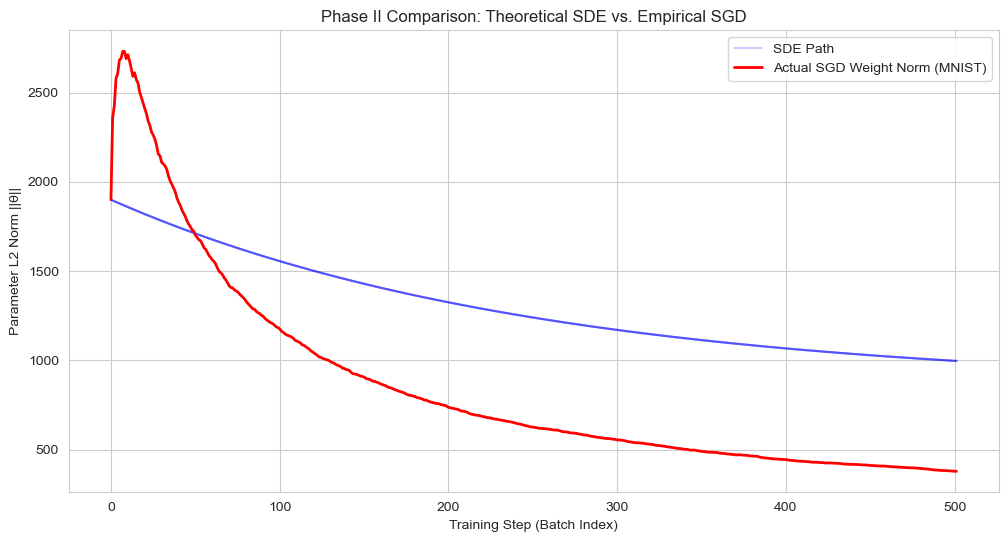

Optimal Drift (Theta): 0.0037
Optimal Diffusion (Sigma): 5.0000


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from scipy.optimize import minimize

# --- 1. SDE Simulator (Mathematical Model) ---
class SDESimulator:
    def __init__(self, drift_func, diffusion_func, paths, points, T=1.0, X0=0.0):
        self.drift_func = drift_func
        self.diffusion_func = diffusion_func
        self.paths = paths
        self.points = points
        self.T = T
        self.X0 = X0
        self.dt = T / (points - 1)
        self.t_axis = np.linspace(0, T, points)

    def simulate(self):
        X = np.zeros((self.paths, self.points))
        X[:, 0] = self.X0
        dW = np.random.normal(0, np.sqrt(self.dt), (self.paths, self.points - 1))
        
        for i in range(self.points - 1):
            # Euler-Maruyama update
            X[:, i+1] = X[:, i] + \
                        self.drift_func(X[:, i], self.t_axis[i]) * self.dt + \
                        self.diffusion_func(X[:, i], self.t_axis[i]) * dW[:, i]
        return X

# --- 2. Classical SGD Training (Empirical Model) ---
def run_sgd_comparison():
    # Setup Data
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

    pipeline = Pipeline([
        ("Scaler", StandardScaler()),
        ("sgd_classifier", SGDClassifier(loss='log_loss', random_state=42, warm_start=True))
    ])

    classes = np.arange(10)
    weight_norms = []
    
    print("Starting SGD Training...")
    # We'll limit to 500 batches for a clear comparison plot
    for batch_idx, (images, labels) in enumerate(train_loader):
        if batch_idx > 500: break
        
        images_np = images.view(images.size(0), -1).numpy()
        labels_np = labels.numpy()

        if batch_idx == 0:
            pipeline.named_steps['sgd_classifier'].partial_fit(images_np, labels_np, classes=classes)
        else:
            pipeline.named_steps['sgd_classifier'].partial_fit(images_np, labels_np)

        # Track the L2 norm of the weights to see "Diffusion"
        weights = pipeline.named_steps['sgd_classifier'].coef_
        weight_norms.append(np.linalg.norm(weights))

    print("Training finished.")
    return np.array(weight_norms)

# --- 3. Execution and Plotting ---
if __name__ == '__main__':
    # A. Run Empirical SGD
    sgd_trajectory = run_sgd_comparison()

    # B. Run SDE Simulation (Modeling the SGD norm evolution)
    # We use Ornstein-Uhlenbeck parameters to mimic weight decay/convergence
    theta_mu = 2.0  # Speed of reversion
    sigma_noise = 0.5  # Volatility of gradients
    
    drift = lambda x, t: -theta_mu * (x - np.mean(sgd_trajectory))
    diffusion = lambda x, t: sigma_noise
    
    sim = SDESimulator(drift, diffusion, paths=5, points=len(sgd_trajectory), T=1.0, X0=sgd_trajectory[0])
    sde_paths = sim.simulate()

    # C. Plot Comparison
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # Plot SDE mathematical paths
    time_axis = np.linspace(0, len(sgd_trajectory), len(sgd_trajectory))
    for i in range(sde_paths.shape[0]):
        plt.plot(time_axis, sde_paths[i, :], color='blue', alpha=0.2, label='SDE Path' if i==0 else "")
    
    # Plot real SGD weight behavior
    plt.plot(time_axis, sgd_trajectory, color='red', lw=2, label='Actual SGD Weight Norm (MNIST)')
    
    plt.title("Phase II Comparison: Theoretical SDE vs. Empirical SGD")
    plt.xlabel("Training Step (Batch Index)")
    plt.ylabel("Parameter L2 Norm ||θ||")
    plt.legend()
    plt.show()

    def estimate_sde_parameters(sgd_trajectory, dt=1.0):
        """
        Fits an Ornstein-Uhlenbeck SDE to the observed SGD trajectory.
        dX_t = theta * (mu - X_t) * dt + sigma * dW_t
        """
        X = sgd_trajectory
        mu_target = np.mean(X[-100:]) # Assume the last 100 steps are "steady state"
        
        def objective(params):
            theta, sigma = params
            if theta <= 0 or sigma <= 0: return 1e9
            
            # Calculate the theoretical transitions
            # For OU process: E[X_{t+1}] = X_t + theta * (mu - X_t) * dt
            predicted_diff = theta * (mu_target - X[:-1]) * dt
            actual_diff = np.diff(X)
            
            # Mean Squared Error of the Drift
            drift_error = np.mean((actual_diff - predicted_diff)**2)
            
            # Residual variance should match sigma^2 * dt
            residual_var = np.var(actual_diff - predicted_diff)
            diffusion_error = (residual_var - (sigma**2 * dt))**2
            
            return drift_error + diffusion_error

        # Initial guess: theta=1.0, sigma=0.1
        res = minimize(objective, [1.0, 0.1], method='L-BFGS-B', bounds=[(1e-3, 10), (1e-3, 5)])
        return res.x, mu_target

    # --- Integration ---
    params, optimized_mu = estimate_sde_parameters(sgd_trajectory)
    opt_theta, opt_sigma = params

    print(f"Optimal Drift (Theta): {opt_theta:.4f}")
    print(f"Optimal Diffusion (Sigma): {opt_sigma:.4f}")

    # Re-run simulation with these "Physical" constants
    drift_opt = lambda x, t: opt_theta * (optimized_mu - x)
    diff_opt = lambda x, t: opt_sigma
    sim_opt = SDESimulator(drift_opt, diff_opt, paths=20, points=len(sgd_trajectory), X0=sgd_trajectory[0])
    X_opt = sim_opt.simulate()